# TPC-C MySQL 17.5 - Application Metrics

* data is generated and loaded into databases in a distributed filesystem
* experiments do not use preloaded data

In [1]:
import pandas as pd
pd.set_option("display.max_rows", None)
pd.set_option('display.max_colwidth', None)
import matplotlib.pyplot as plt
import seaborn as sns
import re
import numpy as np

from bexhoma import collectors

%matplotlib inline

# Collect Results

In [2]:
path = r"C:\data\benchmarks"
#path = r"/home/perdelt/benchmarks"


In [3]:
codes = [
    "1761485837"
]

codes

['1761485837']

In [4]:
collect = collectors.benchbase(path, codes)

# Get all Metrics Metadata

# code = codes[0]
evaluate = collect.get_evaluator(code)
collect.df_metrics = collect.get_metrics(evaluate)

collect.df_metrics

# Get Values Aggregated per SUT and per Experiment

In [6]:
df_performance = collect.get_monitoring_all(type="loading")
df_performance.T

,0
client,1
Memory Usage [MiB],9098.62
Memory Usage Cached [MiB],42257.7
CPU Utilization,0.08
CPU Throttle,0.0
CPU Throttled Time [s],0
CPU Utilization Time [s],433.68
CPU User Time [s],382.99
CPU System Time [s],50.69
Network Rx Total [MiB],811.1


# Barplot of All Metrics for a Single Experiment

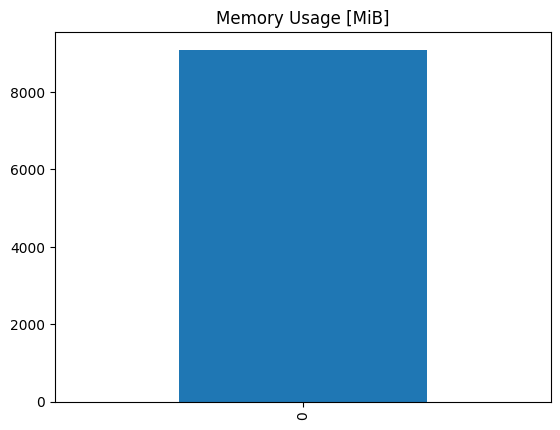

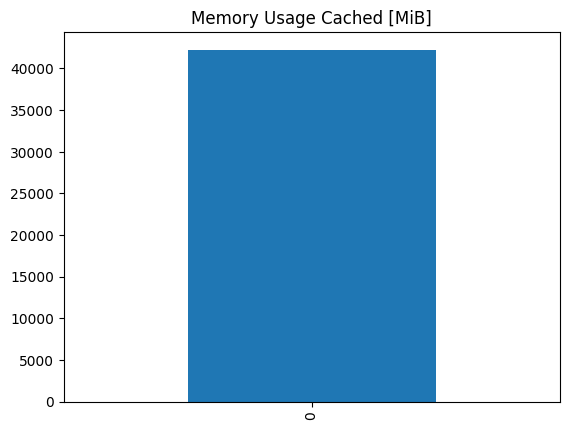

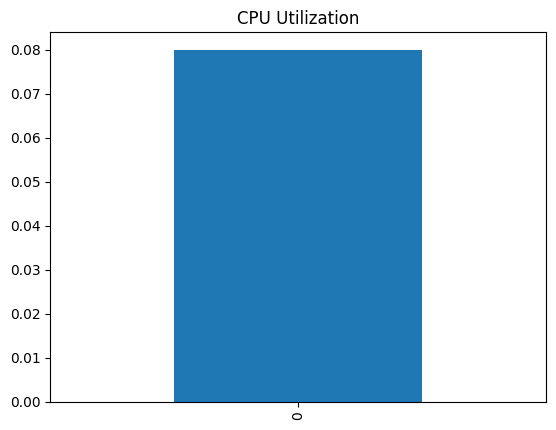

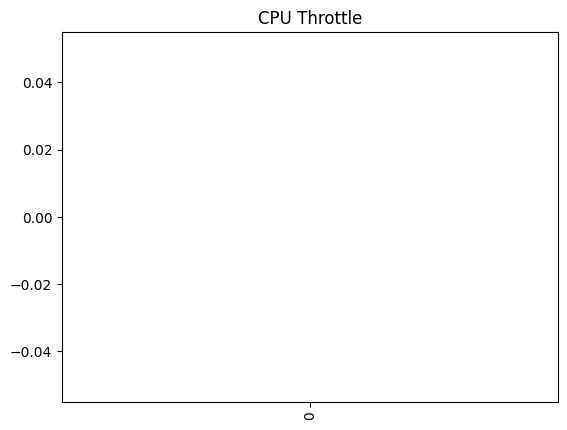

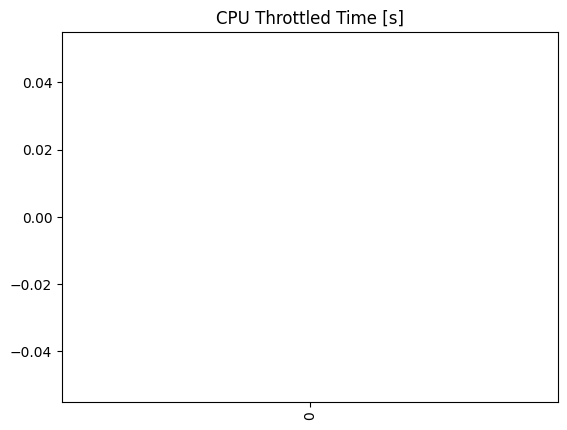

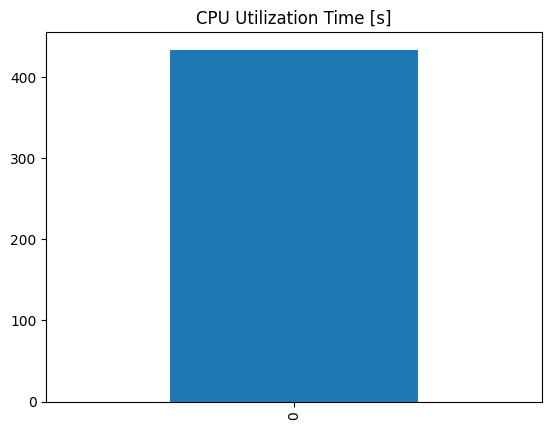

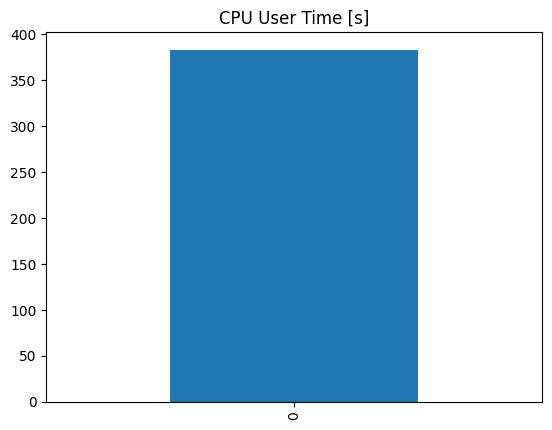

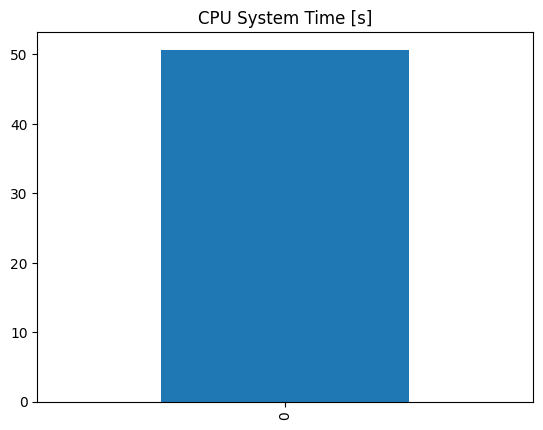

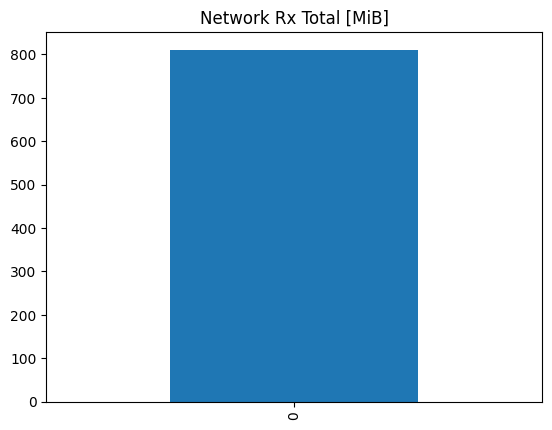

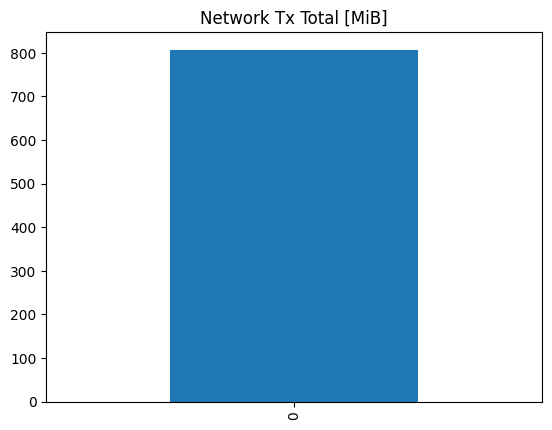

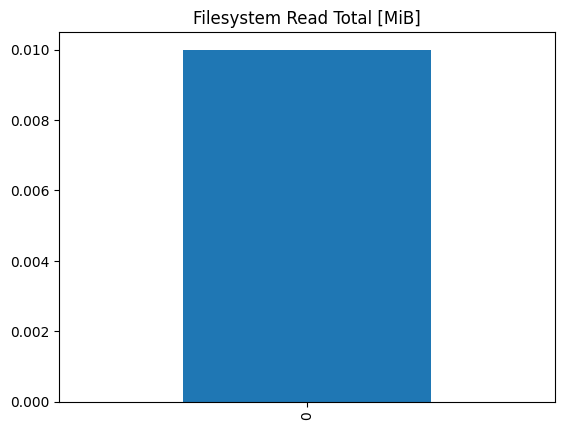

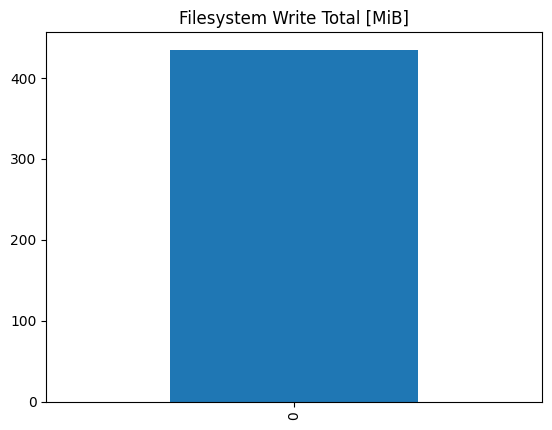

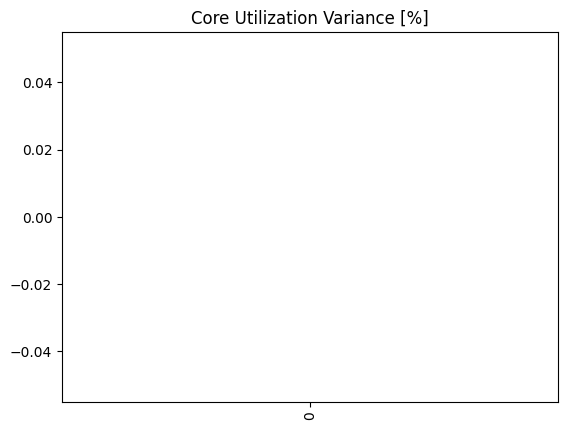

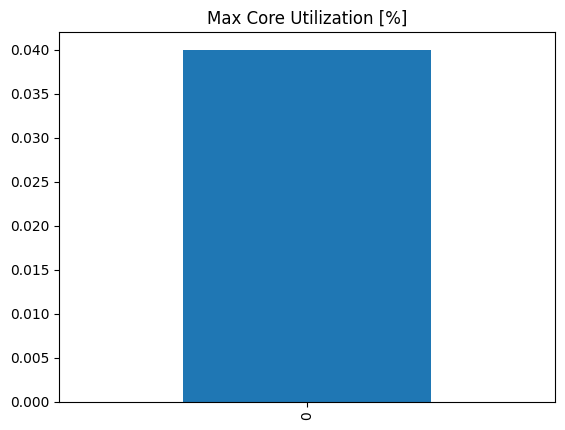

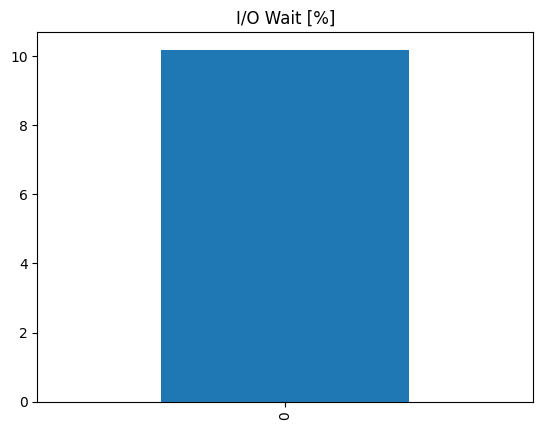

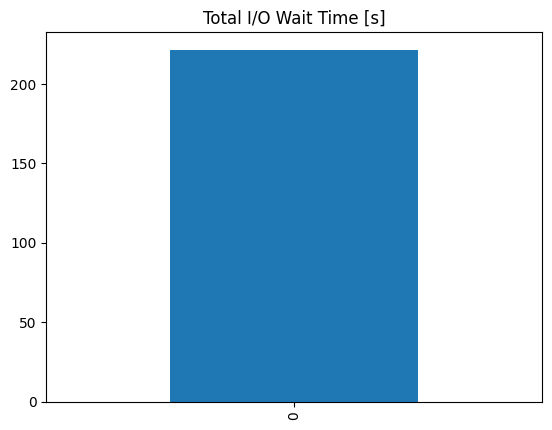

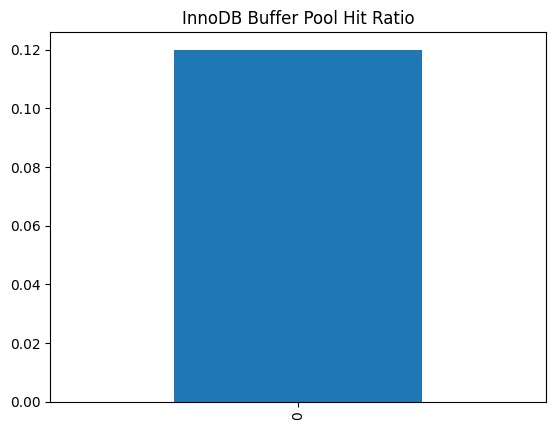

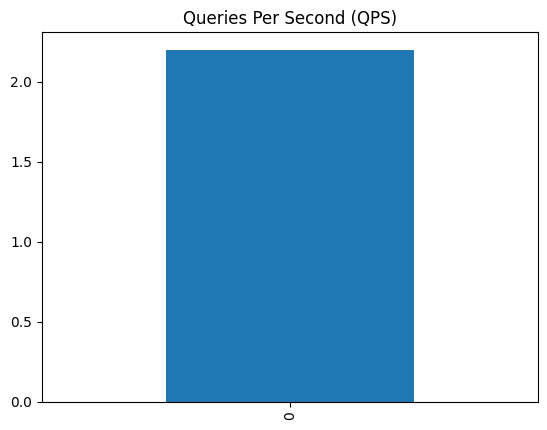

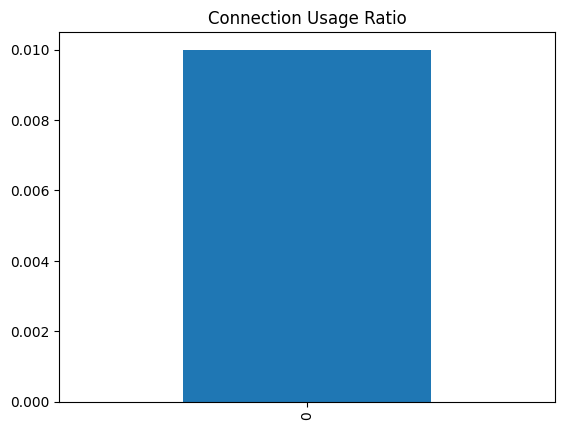

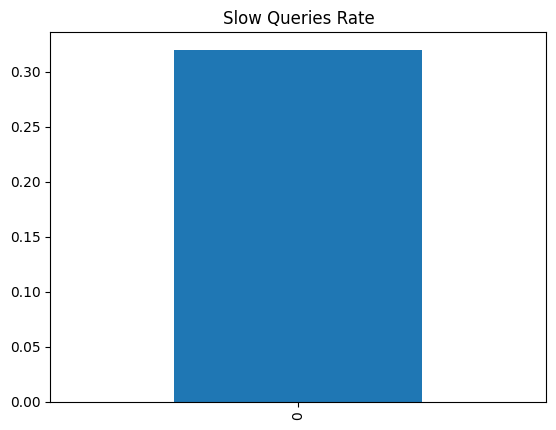

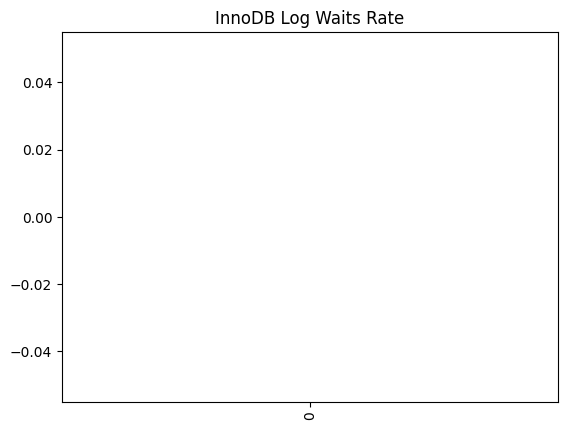

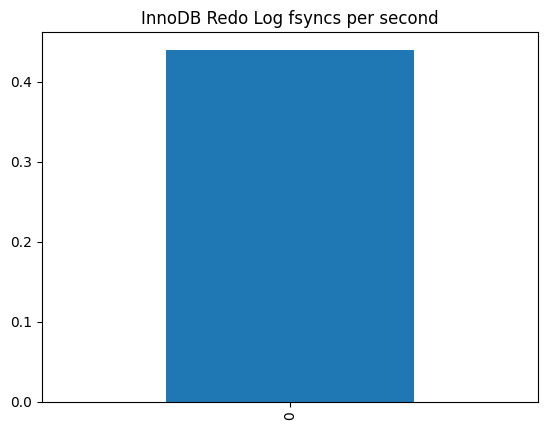

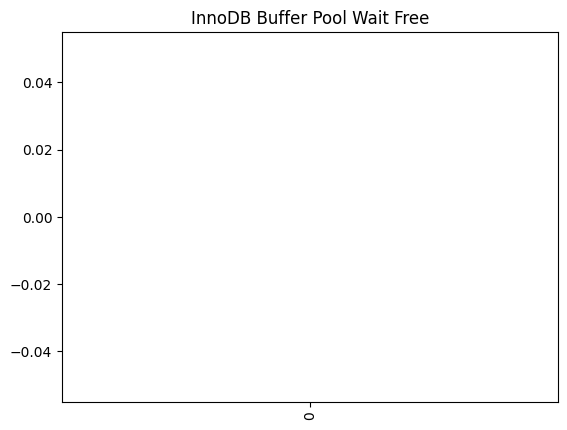

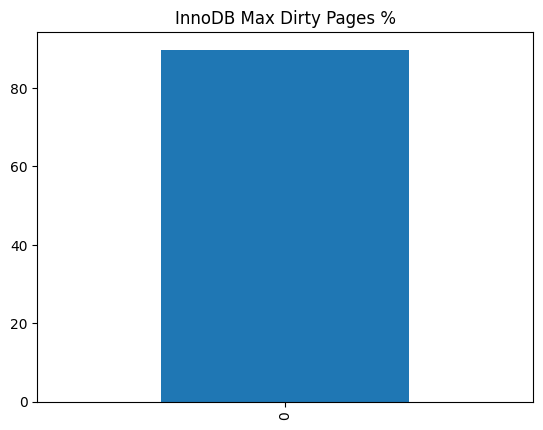

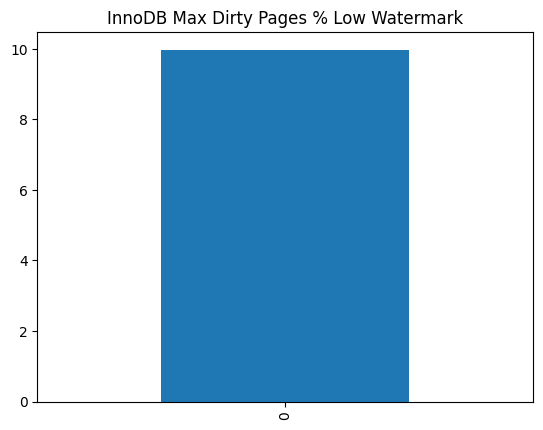

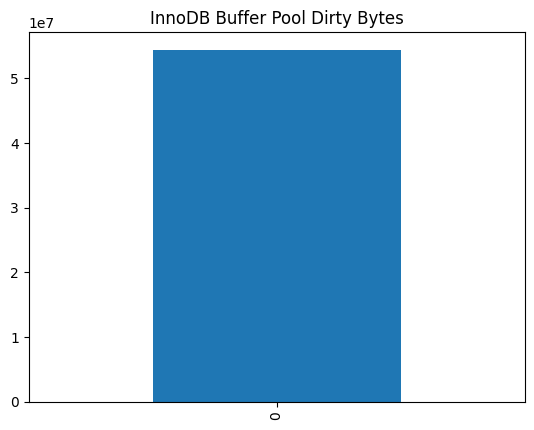

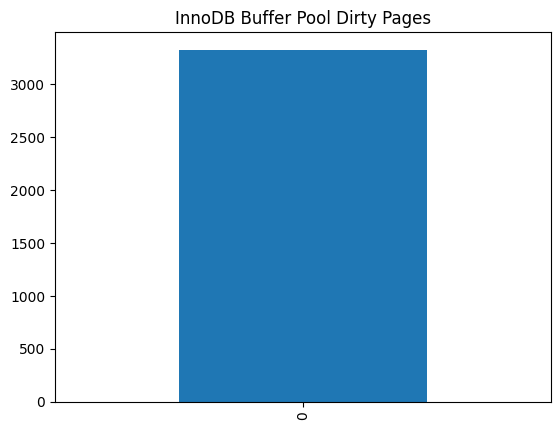

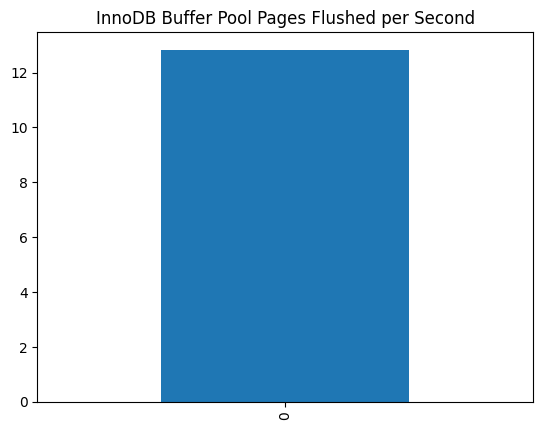

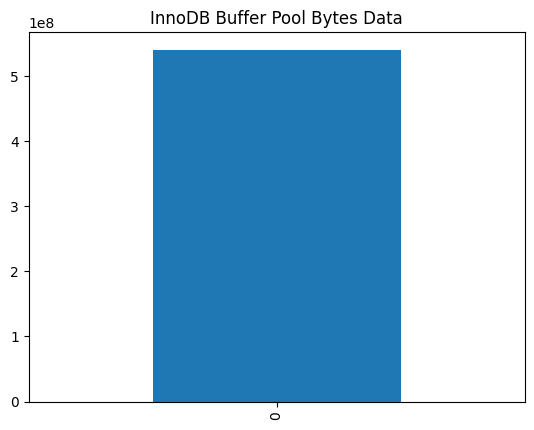

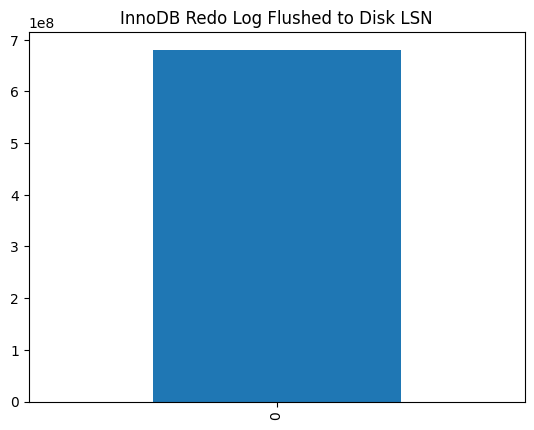

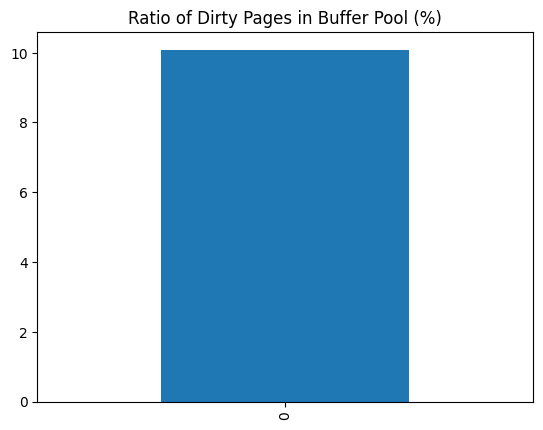

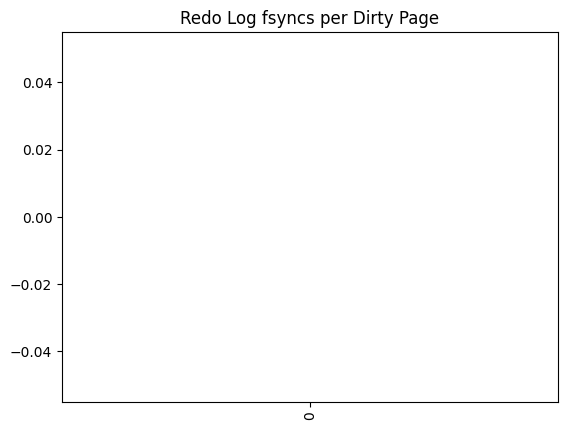

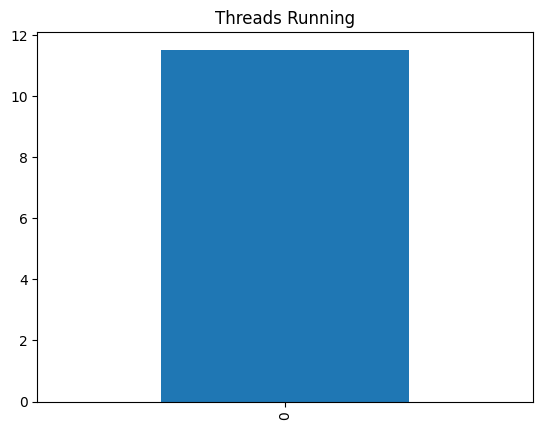

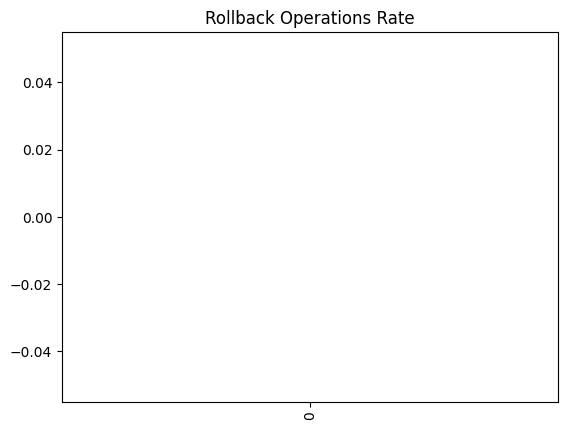

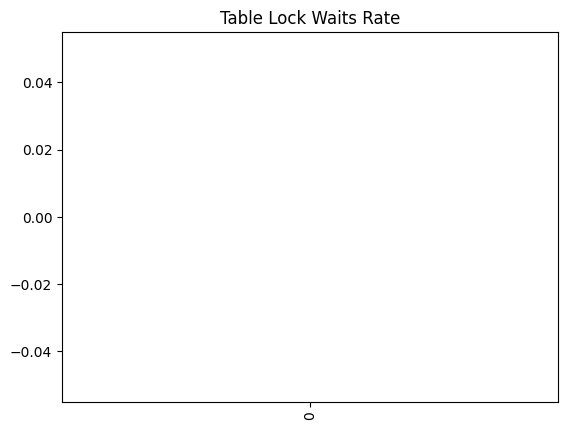

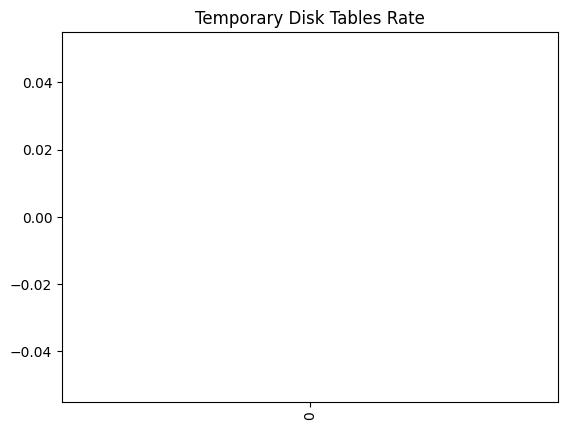

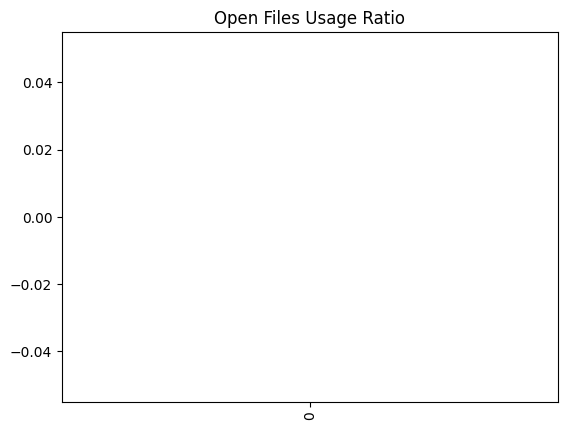

In [7]:
results = []
code = codes[0]
for idx, row in collect.df_metrics.iterrows():
    if row["active"] == False:
        continue
    #print(idx, row["title"])
    metric_name = idx
    method = 'diff' if row["metric"] == 'counter' else 'mean'
    col_name = row["title"]
    #df_monitoring = collect.get_monitoring_single(code, metric=metric_name)
    #print(df_monitoring)
    #plot_boxplots(df_monitoring, y=metric_name, title=col_name)
    ax = df_performance[col_name].plot.bar()
    ax.set_title(col_name)
    plt.show()
    #plot_boxplots(df_performance_first, y='value', title=collect.df_metrics.loc[metric]['title'])

# Boxplot of All Metrics for a Single Experiment

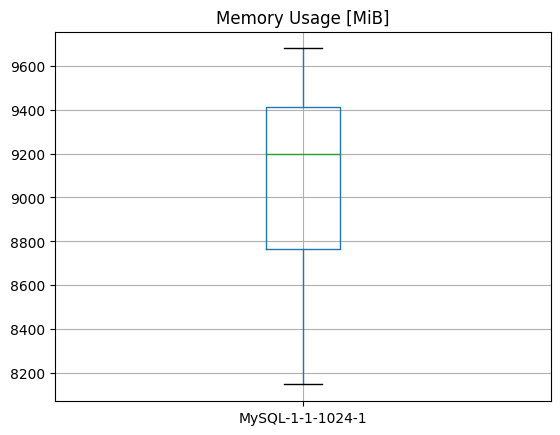

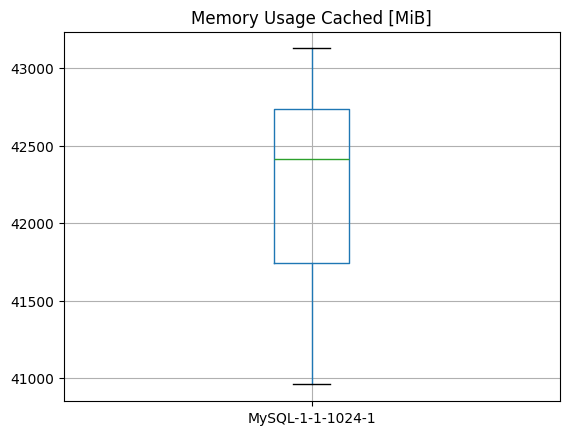

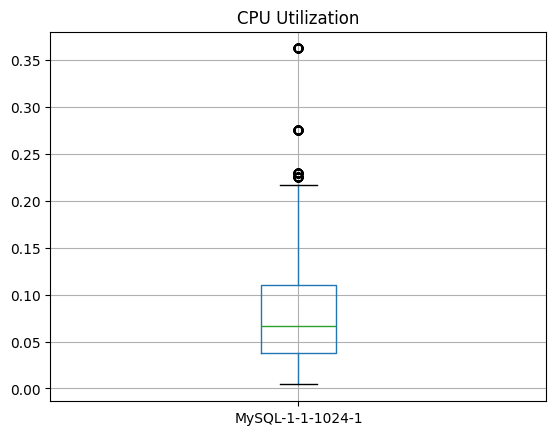

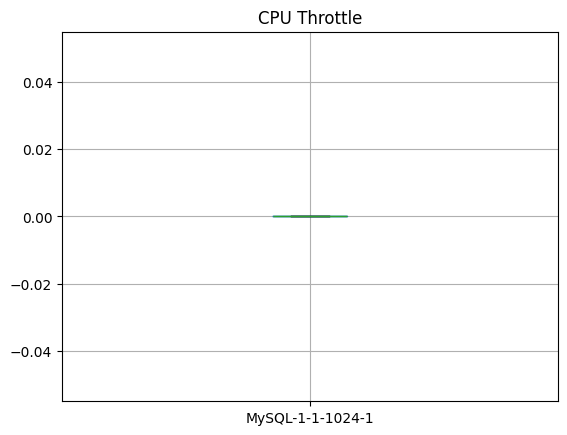

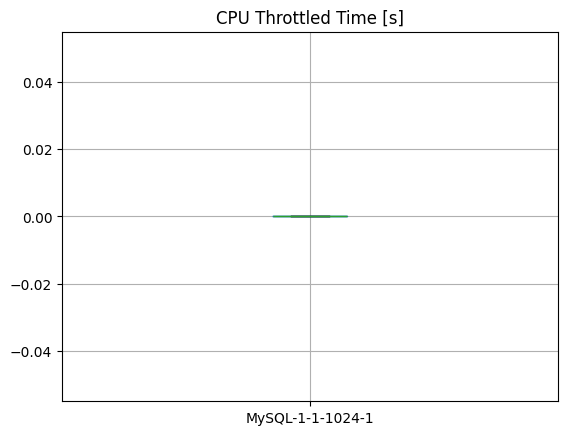

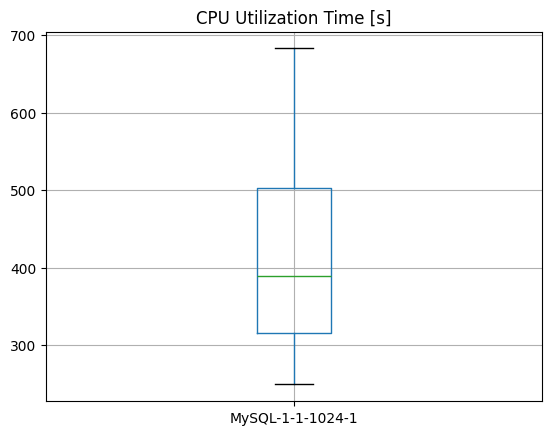

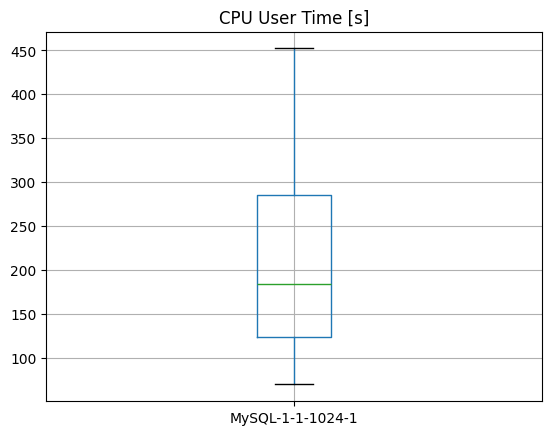

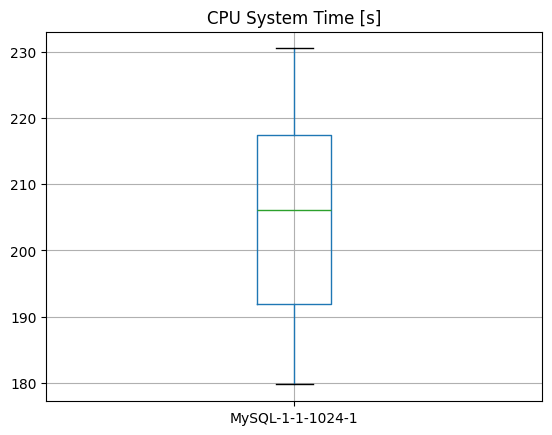

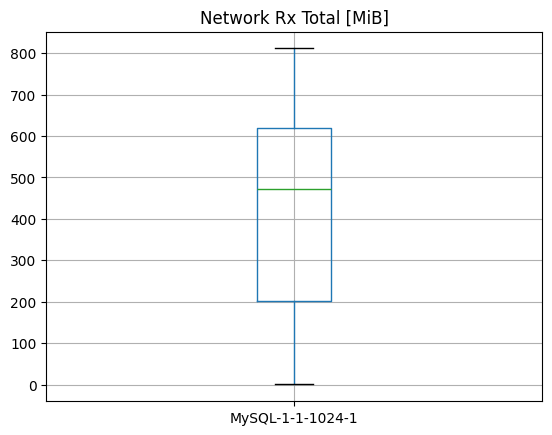

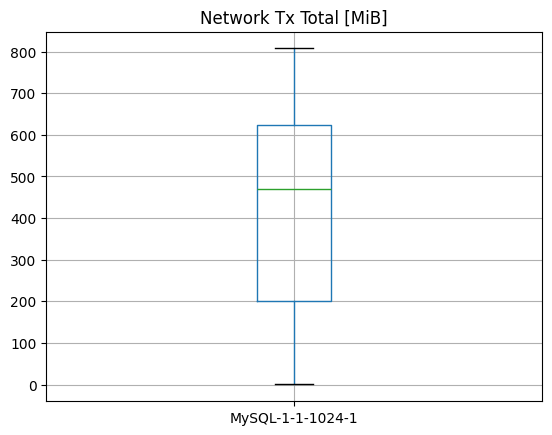

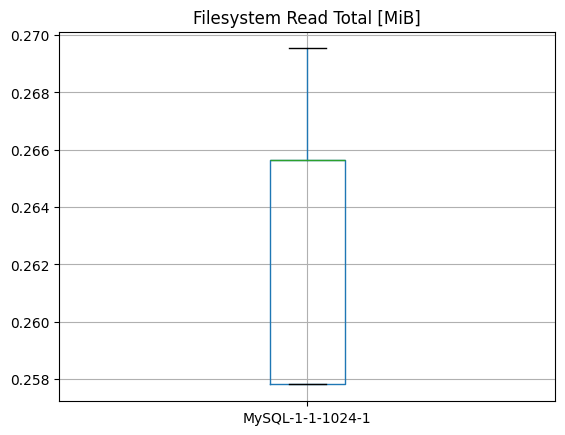

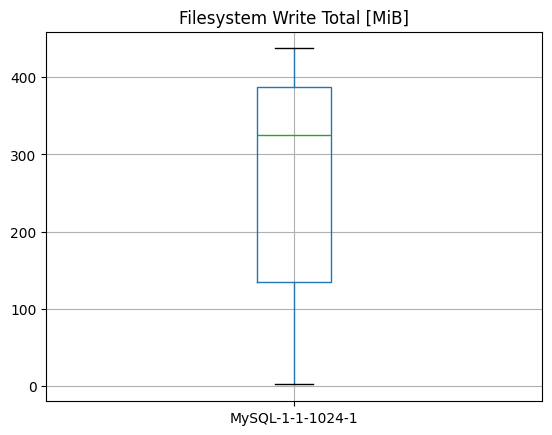

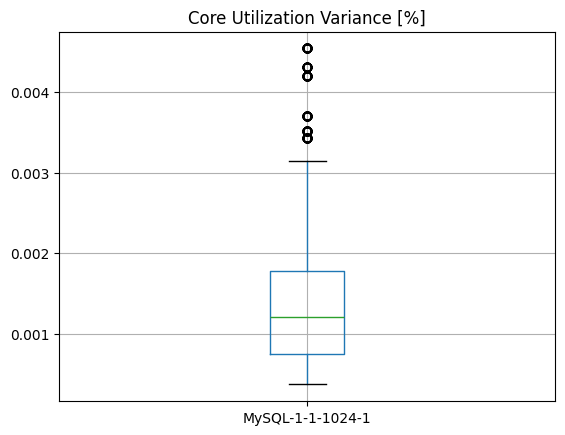

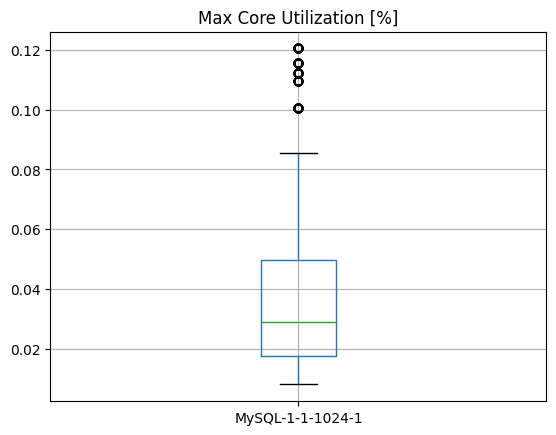

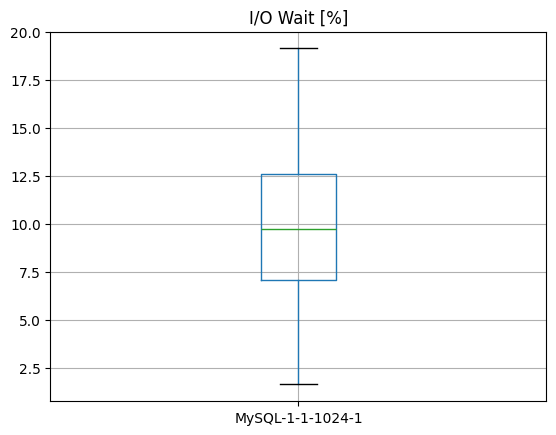

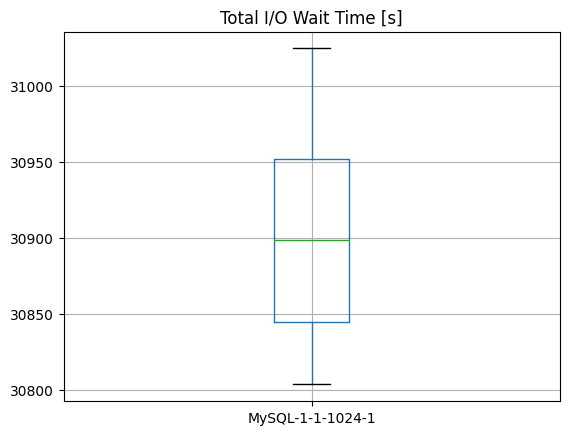

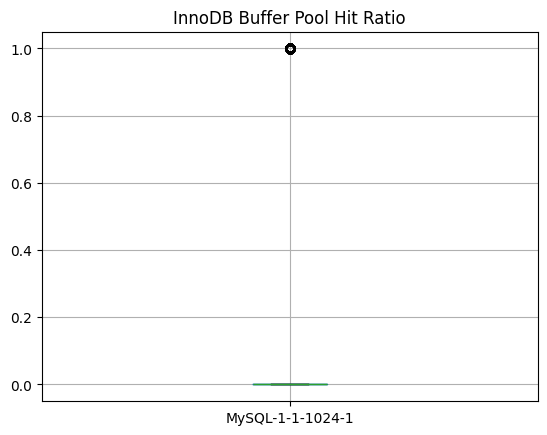

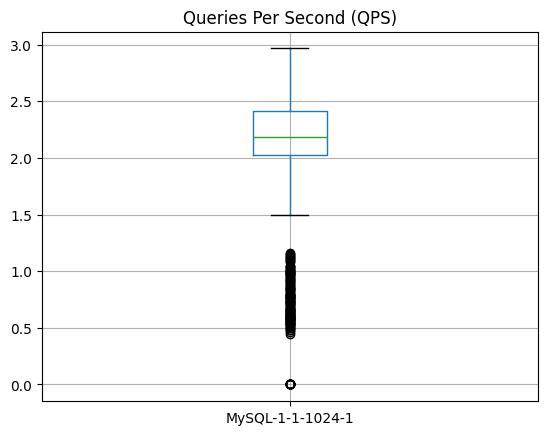

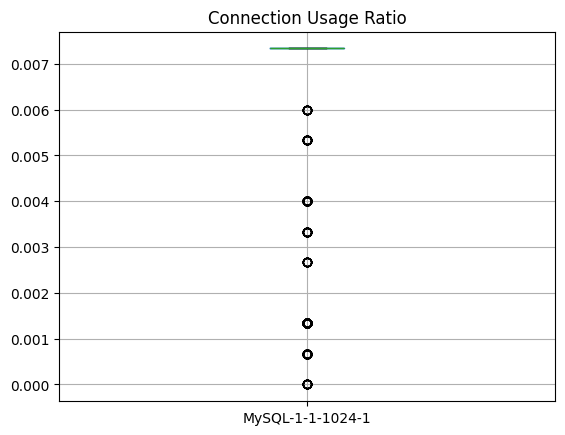

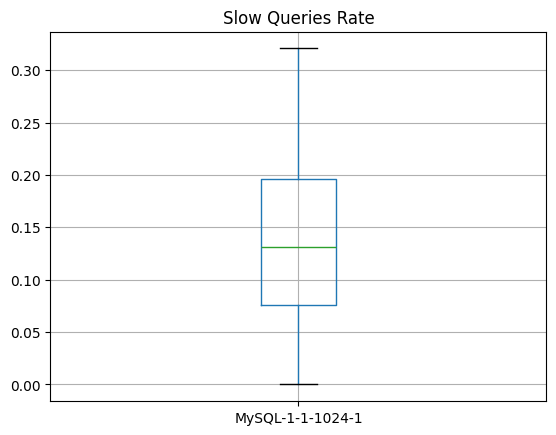

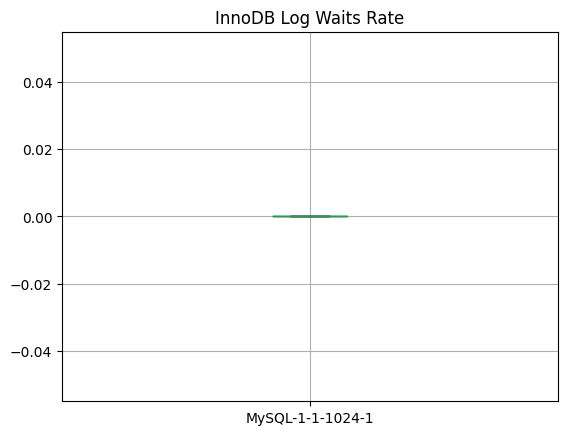

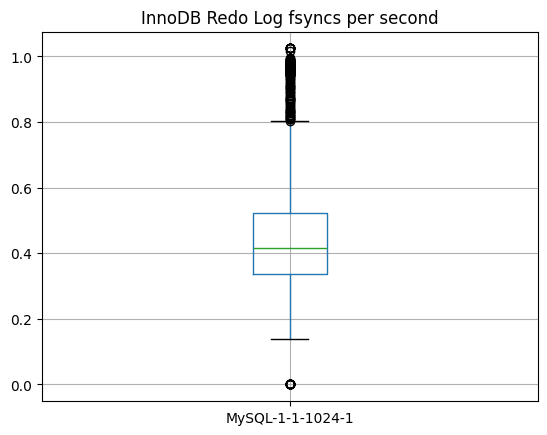

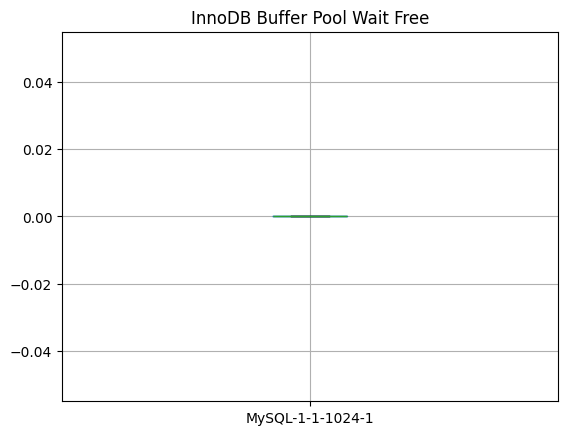

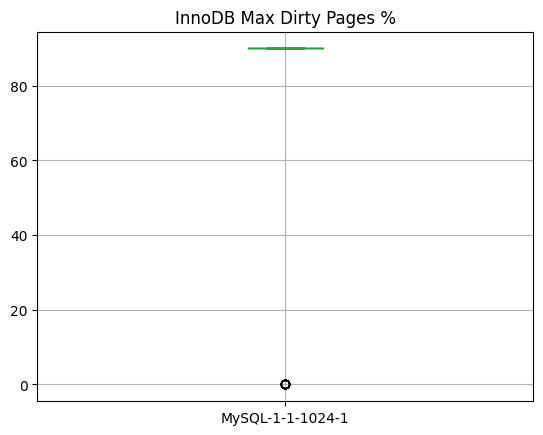

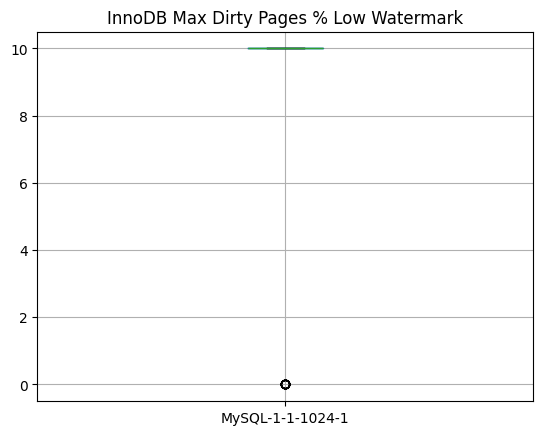

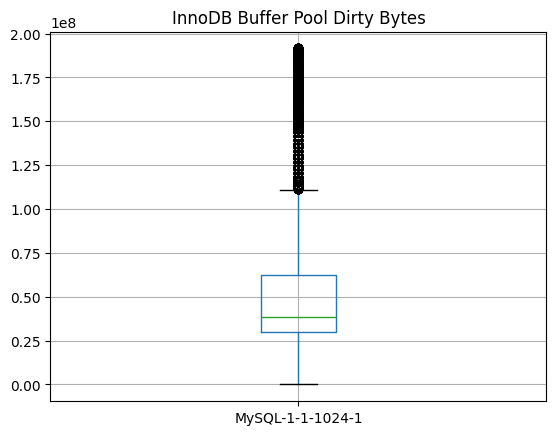

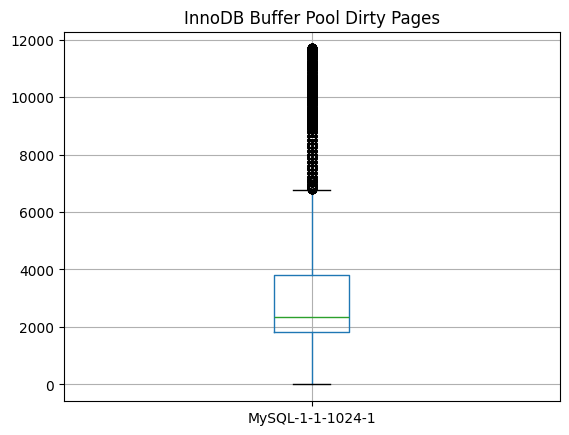

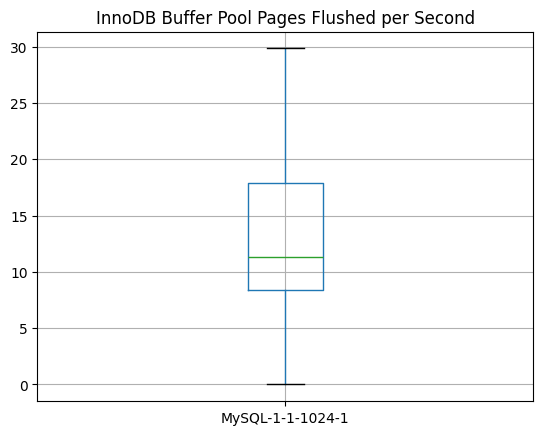

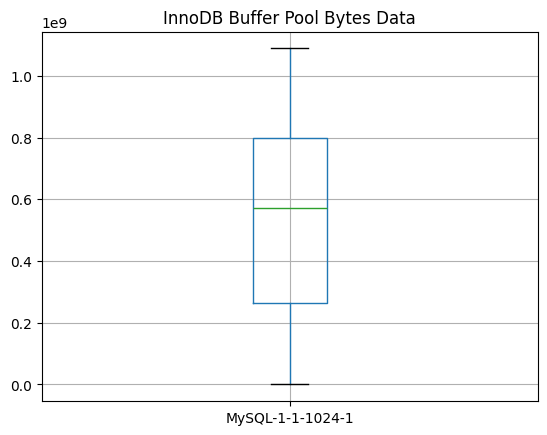

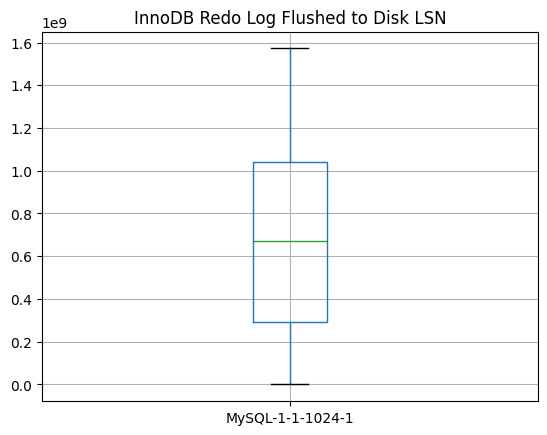

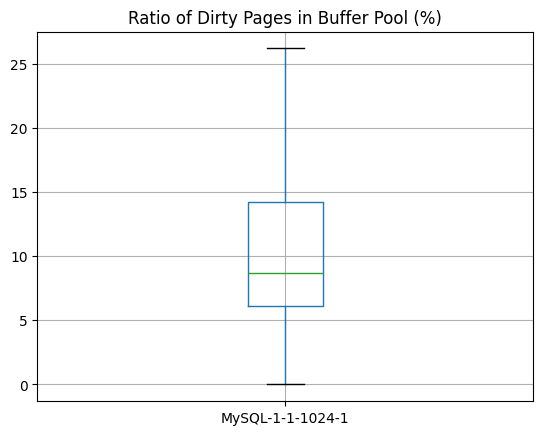

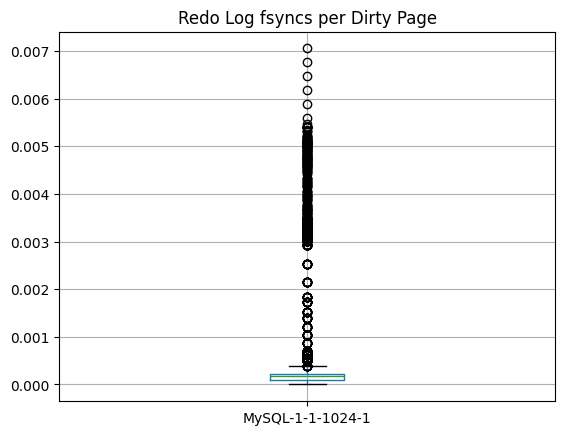

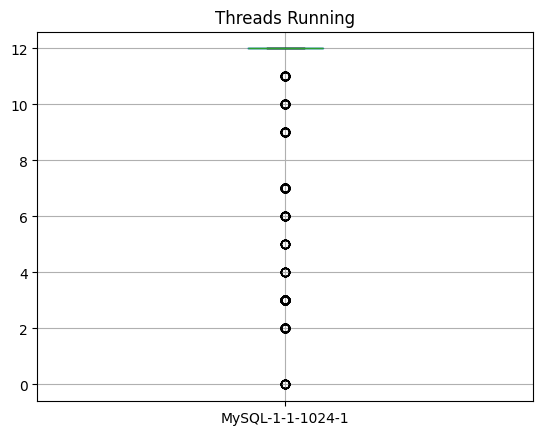

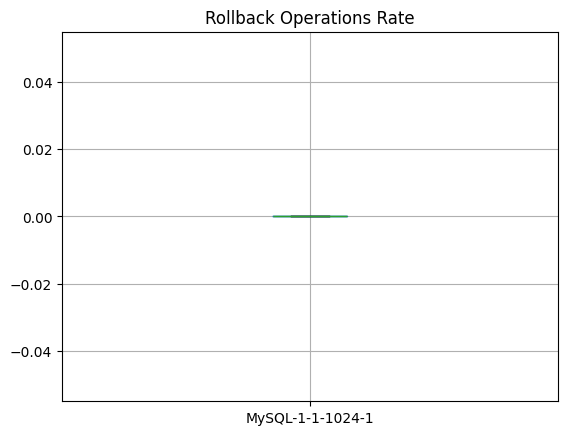

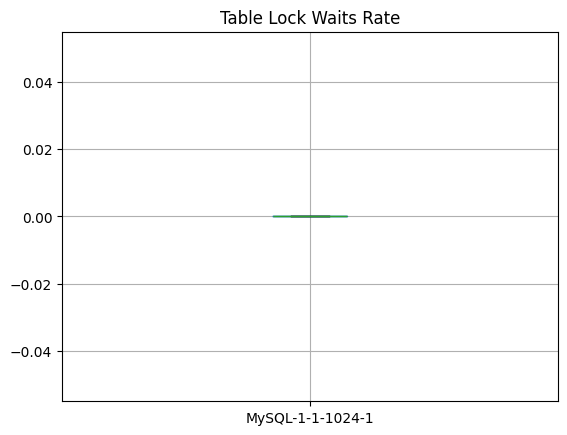

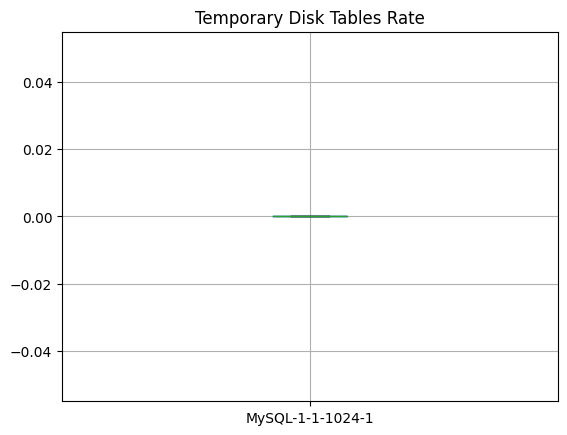

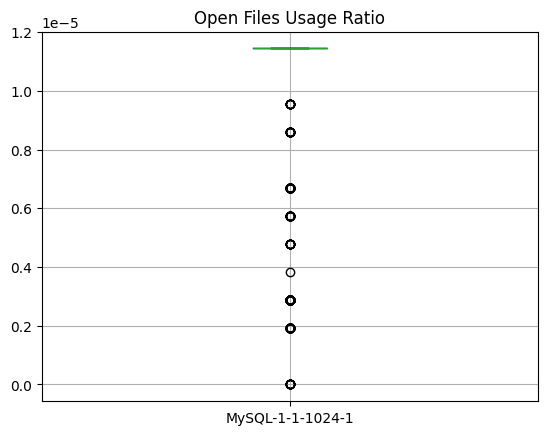

In [12]:
results = []
code = codes[0]
for idx, row in collect.df_metrics.iterrows():
    if row["active"] == False:
        continue
    #print(idx, row["title"])
    metric_name = idx
    method = 'diff' if row["metric"] == 'counter' else 'mean'
    col_name = row["title"]
    df_monitoring = collect.get_monitoring_timeseries_single(code, metric=metric_name, component="loading")
    #print(df_monitoring)
    #plot_boxplots(df_monitoring, y=metric_name, title=col_name)
    ax = df_monitoring.boxplot()
    ax.set_title(col_name)
    plt.show()
    #plot_boxplots(df_performance_first, y='value', title=collect.df_metrics.loc[metric]['title'])

# Boxplot of A Single Metric for a Single Experiment

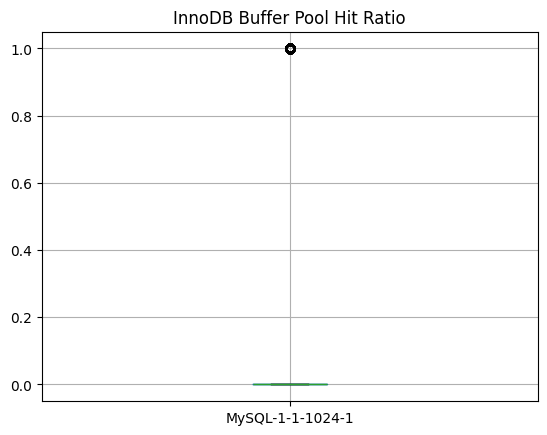

In [9]:
metric = 'mysql_buffer_pool_hit_ratio'
#metric = 'pg_stat_database_blks_reads'
#metric = 'pg_stat_activity_count_idle_transaction'
#metric = 'total_cpu_memory'
code = codes[0]
df_monitoring = collect.get_monitoring_timeseries_single(code, metric=metric, component="loading")

#df_monitoring.plot(title=metric)
#df_monitoring.boxplot()
ax = df_monitoring.boxplot()
ax.set_title(collect.df_metrics.loc[metric]['title'])#metric)
plt.show()

# Lineplot of a Single Metric for a Single Experiment

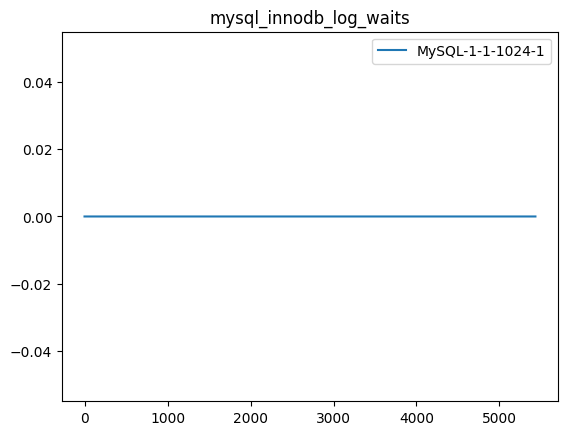

In [17]:
metric = 'pg_stat_database_blks_hit'
metric = 'pg_stat_activity_count_idle_transaction'
metric = 'total_cpu_memory'
metric = 'total_cpu_util'
metric = 'total_cpu_util_s'
metric = 'mysql_innodb_log_waits'

code = codes[0]
df_monitoring = collect.get_monitoring_timeseries_single(code, metric=metric, component="loading")

#df_monitoring.plot(title=metric)
ax = df_monitoring.plot()
ax.set_title(metric)
plt.show()
#df_monitoring

# Performance Metrics

,client,Goodput (requests/second),num_errors,Latency Distribution.Average Latency (microseconds),Latency Distribution.99th Percentile Latency (microseconds),type,num_tenants,code
0,1,74.236656,0,1332895.0,33608686,,0,1761485837


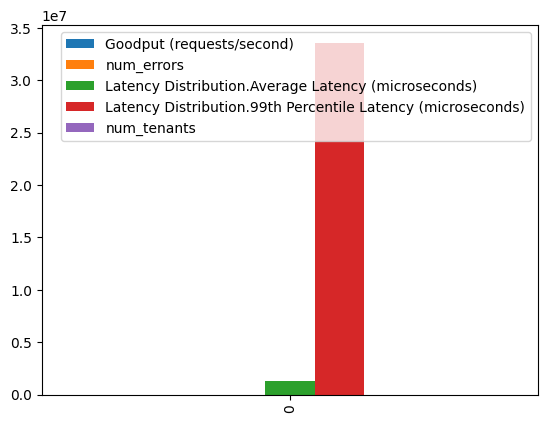

In [18]:
df_performance = collect.get_performance_all()
df_performance.plot.bar()

df_performance